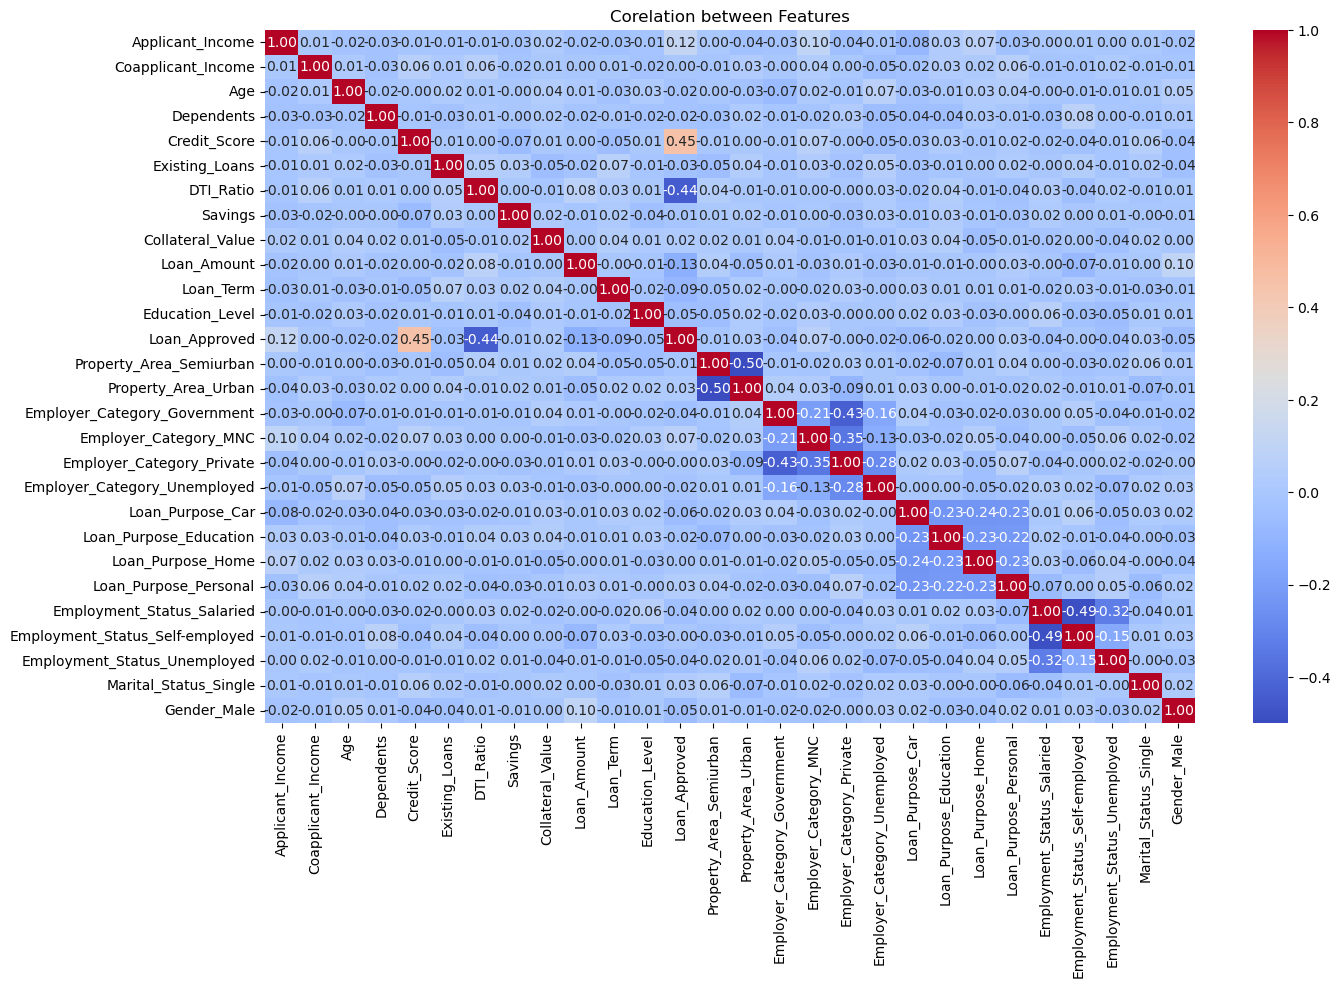

Model name is : logistic_regrestion

Accurecy : 86.0 %
%precision_score : 0.7538461538461538
recall_score : 0.8032786885245902
f1_score : 0.7777777777777778
confusion_matrix 
[[123  16]
 [ 12  49]]

---------------------------------------------------------------------------------------

Model name is : KNN

Accurecy : 73.5 %
%precision_score : 0.5769230769230769
recall_score : 0.4918032786885246
f1_score : 0.5309734513274337
confusion_matrix 
[[117  22]
 [ 31  30]]

---------------------------------------------------------------------------------------

Model name is : Naives_bayes

Accurecy : 86.5 %
%precision_score : 0.7575757575757576
recall_score : 0.819672131147541
f1_score : 0.7874015748031497
confusion_matrix 
[[123  16]
 [ 11  50]]

---------------------------------------------------------------------------------------



In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer  # handling missing values .....

from sklearn.preprocessing import LabelEncoder , OneHotEncoder  # encoding 

from sklearn.model_selection import train_test_split # traing data for model ....

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score , precision_score,recall_score,f1_score , classification_report , confusion_matrix

df = pd.read_csv("loan_approval_data.csv").copy()

Number_cols  = df.select_dtypes(include = ["number"]).columns    # columns separtion for handling missng values 
object_cols  = df.select_dtypes(include = ["object"]).columns  

num_SI = SimpleImputer(strategy="mean")

df[Number_cols] = num_SI.fit_transform(df[Number_cols])  # handling missing data 

Obj_SI = SimpleImputer(strategy="most_frequent")

df[object_cols] = Obj_SI.fit_transform(df[object_cols])

# Encoding  ....................

LE = LabelEncoder()

df["Education_Level"] = LE.fit_transform(df["Education_Level"])    # Ordinal Data 
df["Loan_Approved"] = LE.fit_transform(df["Loan_Approved"])

OHE = OneHotEncoder(handle_unknown = "ignore",sparse_output = False, drop = "first")

cols = ["Property_Area","Employer_Category","Loan_Purpose","Employment_Status","Marital_Status","Gender"]

encoded_array  = OHE.fit_transform(df[cols])
Array_to_DF = pd.DataFrame(encoded_array , columns = OHE.get_feature_names_out(cols) , index = df.index)

new_df = pd.concat([df.drop(columns = cols),Array_to_DF] , axis=1)

new_df = new_df.drop(columns = "Applicant_ID" , axis = 1)  # coz ists unused column 

# Corelational heat map

Num_Cols = new_df.select_dtypes(include = "number")

Corr_matrix = Num_Cols.corr()

plt.figure(figsize=(15,9))
           
sns.heatmap(
    Corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Corelation between Features")
plt.show()

# traing the data for model ....abs
new_df["Credit_Score_sq"] = new_df["Credit_Score"] ** 3
new_df["DTI_Ratio_sq"] = new_df["DTI_Ratio"] ** 3

X = new_df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"] , axis = 1)
Y = new_df["Loan_Approved"]


x_train,x_test,y_train,y_test = train_test_split(X , Y , random_state=42, test_size=0.2)

# scaling 

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression()
model.fit(x_train_scaled,y_train)

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(x_train_scaled,y_train)

model3 = GaussianNB()
model3.fit(x_train_scaled,y_train)

models = {"logistic_regrestion" : model , "KNN" : model2 , "Naives_bayes" : model3 }

for name , model in models.items() :
    y_predict = model.predict(x_test_scaled)
    print(f"Model name is : {name}")
    print()
    print(f"Accurecy : {accuracy_score(y_test, y_predict)*100} %")
    print(f"%precision_score : {precision_score(y_test, y_predict)}")
    print(f"recall_score : {recall_score(y_test, y_predict)}")
    print(f"f1_score : {f1_score(y_test, y_predict)}")
    print(f"confusion_matrix \n{confusion_matrix(y_test, y_predict)}")
    print()
    print("---------------------------------------------------------------------------------------")
    print()

In [165]:
data = [[15000, 5000, 35, 1, 1, 10000, 30000, 20000, 60, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 250000000, 0.04, 0]]
scled_data = scaler.transform(data)
predict = model3.predict(scled_data)
if predict == 1 :
    print("YES Loan will be Provided")
elif predict == 0 :
    print("Sorry Loan will not provided")
else :
    print("Invalid")

YES Loan will be Provided


C:\Users\91983\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
